# Care Transition Efficiency & Placement Outcome Analytics

This notebook performs the initial inspection of the UAC dataset before any data cleaning or analytical calculations are performed.

The purpose of this phase is to understand:
- What information is available in the dataset
- The structure and size of the dataset
- The meaning and format of the variables
- Missing or blank observations
- Duplicate records
- The time period covered by the data
- The frequency of observations
- Basic statistical characteristics of the variables

No observations are removed or modified during this phase unless explicitly stated.

## 1. Project Context

The Unaccompanied Alien Children (UAC) program involves several stages of care, beginning with apprehension and CBP custody and continuing through transfer to HHS care and eventual discharge.

The dataset provides aggregate observations for:

1. Children apprehended and placed in CBP custody
2. Children in CBP custody
3. Children transferred out of CBP custody
4. Children in HHS care
5. Children discharged from HHS care

The overall analytical goal is to move beyond simple population counts and investigate the efficiency and pressure points within the care transition process.

# Data Understanding

## 1.1 Introduction

### Objective

The objective of this phase is to understand the structure, content, and quality of the UAC dataset before performing data cleaning and analytical modeling. The analysis focuses on identifying the available care-stage variables, understanding the reporting period, examining missing or blank records, and assessing the overall structure of the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

## 1.2 Dataset Overview

### Description

The Unaccompanied Alien Children (UAC) Program dataset contains observations related to the movement of children through the federal care and custody process. The dataset includes measures of children entering CBP custody, remaining in CBP custody, being transferred to HHS care, remaining in HHS care, and being discharged from HHS care.

These variables provide the foundation for examining the movement and operational pressure within different stages of the care pipeline.

In [2]:
df = pd.read_csv("../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv")

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1170
Columns: 6


In [4]:
print("Columns in dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in dataset:

1. Date
2. Children apprehended and placed in CBP custody*
3. Children in CBP custody
4. Children transferred out of CBP custody
5. Children in HHS Care
6. Children discharged from HHS Care


### Dataset Information

The dataset structure is examined to determine the number of observations, available variables, data types, and general characteristics of each field.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    str    
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    str    
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), str(2)
memory usage: 69.5 KB


In [6]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0



Last 5 rows:


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
1165,NaN,NaN,NaN,NaN,NaN,NaN
1166,NaN,NaN,NaN,NaN,NaN,NaN
1167,NaN,NaN,NaN,NaN,NaN,NaN
1168,NaN,NaN,NaN,NaN,NaN,NaN
1169,NaN,NaN,NaN,NaN,NaN,NaN


## 1.3 Data Quality Assessment

### Objective

The objective of this section is to identify potential data quality issues that may affect subsequent analysis. Missing values, completely blank records, duplicate observations, and invalid or unexpected values are examined before any transformation is performed.

In [7]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

display(missing_summary)

,Missing Values,Missing Percentage
Date,450,38.461538
Children apprehended and placed in CBP custody*,450,38.461538
Children in CBP custody,450,38.461538
Children transferred out of CBP custody,450,38.461538
Children in HHS Care,450,38.461538
Children discharged from HHS Care,450,38.461538


## 1.4 Temporal Structure

### Description

The dataset contains observations recorded across multiple dates. Examining the date range and reporting intervals is important because the later analysis will rely on temporal trends and changes in activity across the care pipeline.

The presence of gaps between observations is also examined to distinguish unavailable reporting dates from periods of zero activity.

In [8]:
blank_rows = df.isna().all(axis=1).sum()

print("Completely blank rows:", blank_rows)

Completely blank rows: 450


In [9]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 449


## 1.5 Descriptive Statistics

### Description

Descriptive statistics are used to understand the typical level and variation of each numerical measure. Minimum, maximum, mean, median, and dispersion provide an initial view of the scale of activity across CBP custody, transfers, HHS care, and discharges.

In [10]:
for column in df.columns:
    print(f"\n--- {column} ---")
    print("Unique values:", df[column].nunique())
    print(df[column].dropna().unique()[:10])


--- Date ---
Unique values: 720
<ArrowStringArray>
['December 21, 2025', 'December 18, 2025', 'December 17, 2025',
 'December 16, 2025', 'December 15, 2025', 'December 14, 2025',
 'December 11, 2025', 'December 10, 2025', 'December 09, 2025',
 'December 08, 2025']
Length: 10, dtype: str

--- Children apprehended and placed in CBP custody* ---
Unique values: 169
[ 6. 11.  7.  8. 10.  4.  9. 16.  3. 18.]

--- Children in CBP custody ---
Unique values: 216
[18. 50. 31. 54. 42. 35. 47. 30. 27. 24.]

--- Children transferred out of CBP custody ---
Unique values: 185
[11.  6. 15.  9.  4.  5.  7. 13.  8. 10.]

--- Children in HHS Care ---
Unique values: 642
<ArrowStringArray>
['2,484', '2,472', '2,481', '2,468', '2,470', '2,462', '2,437', '2,439',
 '2,443', '2,440']
Length: 10, dtype: str

--- Children discharged from HHS Care ---
Unique values: 285
[14. 16. 10.  9.  7.  8.  4. 12. 13.  0.]


## 1.6 Reporting Pattern Analysis

### Objective

The distribution of observations across days of the week is examined to determine whether the dataset follows a consistent reporting pattern or contains systematic gaps in specific periods.

In [11]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Minimum date:", df["Date"].min())
print("Maximum date:", df["Date"].max())

Minimum date: 2023-01-12 00:00:00
Maximum date: 2025-12-21 00:00:00


In [12]:
invalid_dates = df["Date"].isna().sum()

print("Invalid/missing dates:", invalid_dates)

Invalid/missing dates: 450


In [13]:
date_check = df.dropna(subset=["Date"]).sort_values("Date").copy()

date_check["Date_Gap"] = date_check["Date"].diff().dt.days

display(
    date_check["Date_Gap"]
    .value_counts()
    .sort_index()
)

Date_Gap
1.0     558
2.0      10
3.0     122
4.0      23
5.0       3
6.0       1
7.0       1
10.0      1
Name: count, dtype: int64

In [14]:
gap_summary = (
    date_check["Date_Gap"]
    .value_counts()
    .sort_index()
    .rename_axis("Days Between Observations")
    .reset_index(name="Number of Occurrences")
)

display(gap_summary)

,Days Between Observations,Number of Occurrences
0,1.0,558
1,2.0,10
2,3.0,122
3,4.0,23
4,5.0,3
5,6.0,1
6,7.0,1
7,10.0,1


In [15]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numeric columns:")
print(list(numeric_columns))

Numeric columns:
['Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children discharged from HHS Care']


In [16]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Children apprehended and placed in CBP custody*,720.0,93.523611,72.646625,0.0,12.00,99.0,147.25,333.0
Children in CBP custody,720.0,171.494444,126.354965,7.0,36.00,193.0,263.25,531.0
Children transferred out of CBP custody,720.0,128.668056,97.322012,0.0,14.00,157.0,199.25,440.0
Children discharged from HHS Care,720.0,173.406944,125.702841,0.0,19.75,181.0,267.00,505.0


In [17]:
summary = df[numeric_columns].describe().T

summary = summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

display(summary)

,count,mean,std,min,25%,50%,75%,max
Children apprehended and placed in CBP custody*,720.0,93.523611,72.646625,0.0,12.00,99.0,147.25,333.0
Children in CBP custody,720.0,171.494444,126.354965,7.0,36.00,193.0,263.25,531.0
Children transferred out of CBP custody,720.0,128.668056,97.322012,0.0,14.00,157.0,199.25,440.0
Children discharged from HHS Care,720.0,173.406944,125.702841,0.0,19.75,181.0,267.00,505.0


In [18]:
df["Day_of_Week"] = df["Date"].dt.day_name()

day_counts = df["Day_of_Week"].value_counts()

display(day_counts)

Day_of_Week
Tuesday      149
Thursday     147
Wednesday    147
Monday       145
Sunday       130
Friday         2
Name: count, dtype: int64

In [19]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_counts = (
    df["Day_of_Week"]
    .value_counts()
    .reindex(weekday_order)
    .fillna(0)
    .astype(int)
)

display(weekday_counts)

Day_of_Week
Monday       145
Tuesday      149
Wednesday    147
Thursday     147
Friday         2
Saturday       0
Sunday       130
Name: count, dtype: int64

In [20]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

print("Years available:")
print(sorted(df["Year"].dropna().unique()))

print("\nNumber of observations by year:")
display(df["Year"].value_counts().sort_index())

Years available:
[np.float64(2023.0), np.float64(2024.0), np.float64(2025.0)]

Number of observations by year:


Year
2023.0    230
2024.0    251
2025.0    239
Name: count, dtype: int64

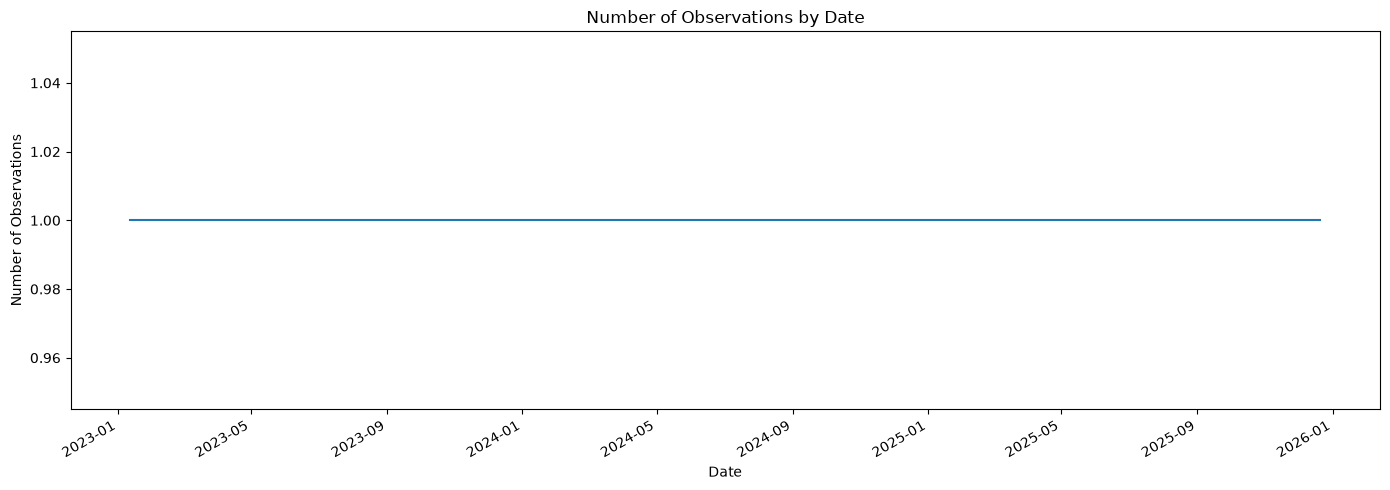

In [21]:
observations_by_date = (
    df.groupby("Date")
    .size()
)

plt.figure(figsize=(14, 5))

observations_by_date.plot()

plt.title("Number of Observations by Date")
plt.xlabel("Date")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

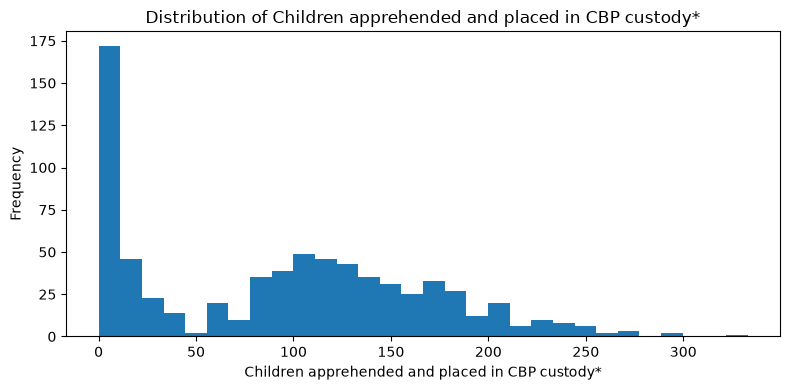

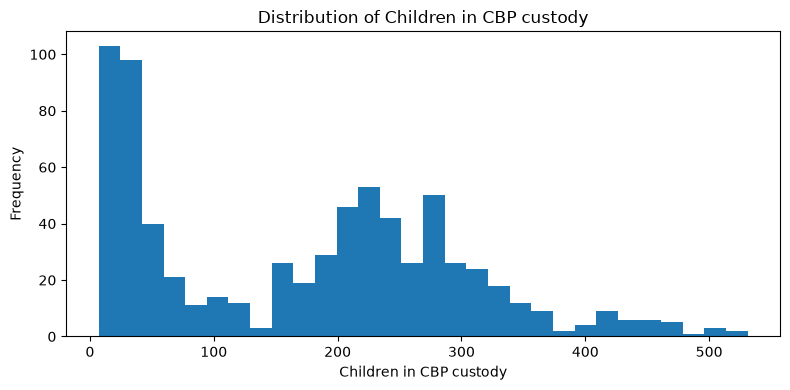

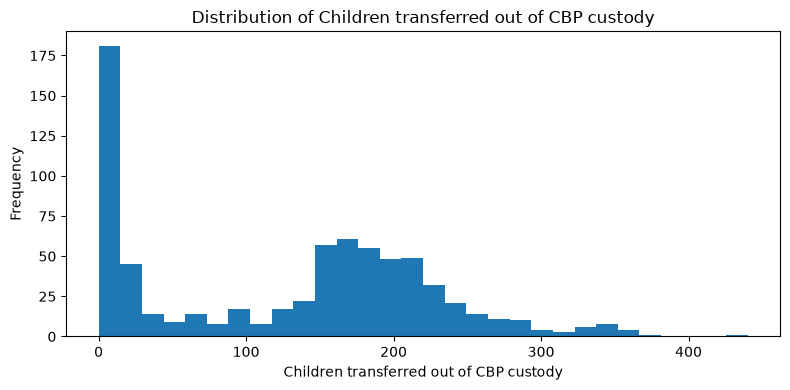

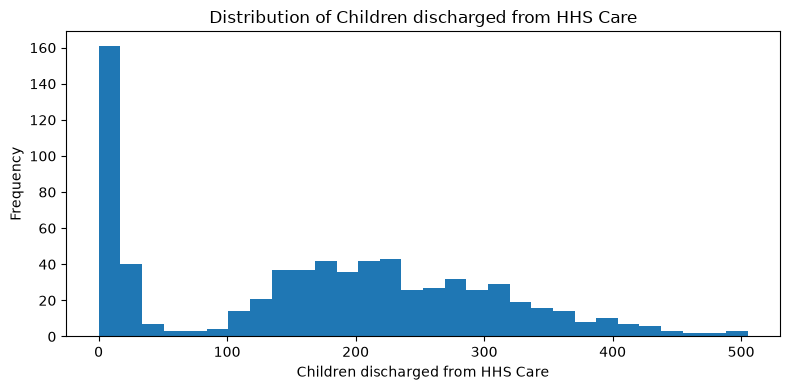

In [22]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))

    plt.hist(df[column].dropna(), bins=30)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

C:\Users\abhin\AppData\Local\Temp\ipykernel_4864\221820387.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


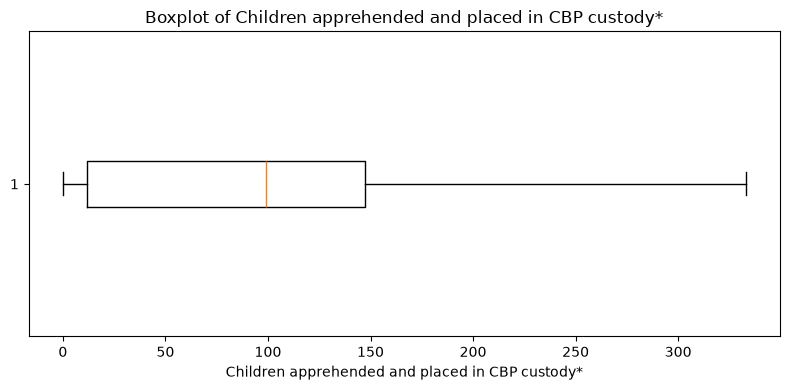

C:\Users\abhin\AppData\Local\Temp\ipykernel_4864\221820387.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


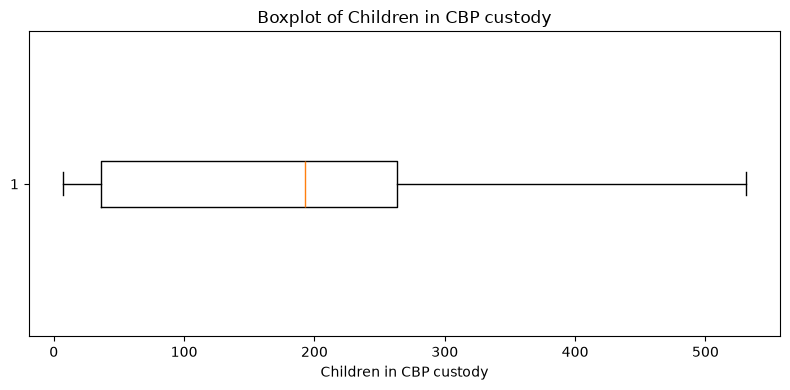

C:\Users\abhin\AppData\Local\Temp\ipykernel_4864\221820387.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


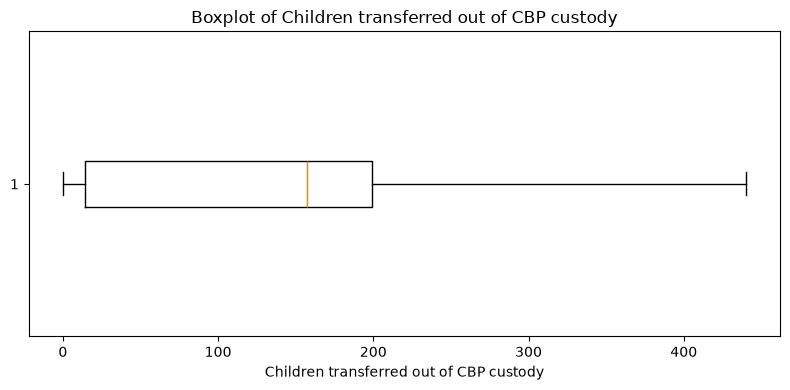

C:\Users\abhin\AppData\Local\Temp\ipykernel_4864\221820387.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


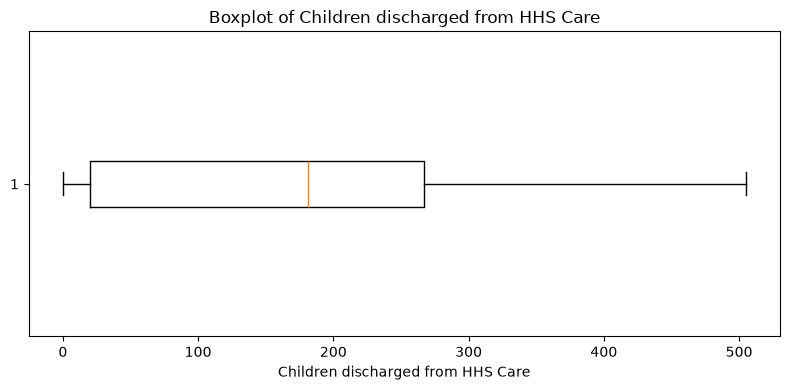

In [23]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))

    plt.boxplot(df[column].dropna(), vert=False)

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [24]:
phase1_report = {
    "Raw rows": len(df),
    "Columns": len(df.columns),
    "Completely blank rows": df.isna().all(axis=1).sum(),
    "Duplicate rows": df.duplicated().sum(),
    "Missing Date values": df["Date"].isna().sum(),
    "Minimum Date": df["Date"].min(),
    "Maximum Date": df["Date"].max(),
}

phase1_report

{'Raw rows': 1170,
 'Columns': 9,
 'Completely blank rows': np.int64(450),
 'Duplicate rows': np.int64(449),
 'Missing Date values': np.int64(450),
 'Minimum Date': Timestamp('2023-01-12 00:00:00'),
 'Maximum Date': Timestamp('2025-12-21 00:00:00')}

In [25]:
for key, value in phase1_report.items():
    print(f"{key}: {value}")

Raw rows: 1170
Columns: 9
Completely blank rows: 450
Duplicate rows: 449
Missing Date values: 450
Minimum Date: 2023-01-12 00:00:00
Maximum Date: 2025-12-21 00:00:00


---

## 1.7 Key Findings

The initial assessment provides an overview of the structure and reporting characteristics of the UAC dataset. The analysis identifies the available care-stage measures, the overall observation period, the presence of blank records, and gaps in reporting dates.

The variables also operate at substantially different scales, particularly between CBP-related measures and the larger HHS care population. This difference will be considered when visualizing and comparing the stages of the care pipeline.

### Conclusion

The data understanding phase establishes the structure and quality characteristics of the dataset required for further analysis. The identified blank records, formatting differences, and temporal gaps will be addressed during the data cleaning phase while preserving the original reporting information.

